# UE M2 Master MAS-MSS et CMI ISI --- Défi IA

# Projet 1: Classification d'images avec des réseaux de neurones profonds
<a href="https://www.python.org/"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/f8/Python_logo_and_wordmark.svg/390px-Python_logo_and_wordmark.svg.png" style="max-width: 150px; display: inline" alt="Python"/></a> & <a href="https://pytorch.org/">
    <img src="https://raw.githubusercontent.com/pytorch/pytorch/master/docs/source/_static/img/pytorch-logo-dark.png" style="max-width: 200px; transform: scale(0.1);" alt="PyTorch"/>
</a>



**Résumé**: Dans ce projet, vous allez devoir implémenter des réseaux de neurones en `PyTorch` pour classifier des images couleurs de taille $3\times 128\times 128$ en $2$ classes (présence ou absence d'une éolienne dans des images satellites).

Nous vous fournisson un ensemble de données d'apprentissage de $32000$ images qui sont labélisées (c'est à dire que l'on vous fourni la classe de chaque image: présence ou abscence d'éoliennes), ainsi qu'un jeu de données de `validation` pour vérifier que votre modèle généralise bien sur des données qu'il n'a jamais vu.

**Évaluation**: Pour être évalués, votre réseau de neurone sera utilisé pour classifier $5000$ nouvelles images d'éolienne **auxquelles vous n'avez pas accès** (comme dans la vrai vie où l'on entraîne un modèle sur des données et l'on l'utilise sur de nouvelles données jamais vues avant). *À vous donc de vous assurez que votre modèle généralise bien*, en particulier grâce aux moyens vu au CM3. Veillez à vous assurer que le script à la fin de ce notebook fonctionne bien sur dossier `evaluation_finale`. (evaluation_finale contient 5000 images mais ce ne sont pas celles sur lesquelles vous serez réellement évalués).

Vous pouvez télécharger les données liées à ce projet dans les liens suivants :

1) Petit jeu de données (Small) :

https://filesender.renater.fr/?s=download&token=b378add0-833b-4194-8880-07a259b29cc1

2) Jeu de données complet :

https://filesender.renater.fr/?s=download&token=caf645fb-2193-4fc9-9b70-1d26053eb05f


Les attendus du projet sont :

- un court compte-rendu qui présente le meilleur modèle que vous avez obtenu, les idées qui vous ont amené à le concevoir, et sa validation à l'aide des données d'apprentissage,

- un fichier .csv qui contient les prédictions des classes pour les images de l'ensemble test à partir duquel un taux de bonne classification sera calculé en fin de projet (voir code à la fin du notebook).

Dans ce travail, vous pouvez créer vos propres architectures de réseaux de neurones, mais également utiliser des modèles pré-entraînés sur d'autres bases de données et les adapter à la problématique de classification d'images de ce projet. En PyTorch, vous pouvez utiliser des modèles pré-entraînés à partir de la bibliothèque torchvision.models, tels que ResNet, VGG, DenseNet, ou encore EfficientNet, et les ajuster (fine-tuning) à vos propres données. Un tutoriel sur l'apprentissage par transfert (qui ne sera abbordé que dans la deuxième partie du cours) en PyTorch est disponible ici :

https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

## 1 Prise en main des données

On donne ci-dessous un exemple code qui permet de lire une image de la base d'apprentissage pour chaque classe.

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# Pytorch
import torch
from torchvision import datasets, transforms, models #transformation des données
from torch.utils.data import DataLoader #Pour ne pas charger toutes les données en mémoire d'un coup
import torch.nn #Module neural networks
import torch.optim #Module optimizers
from tqdm.notebook import tqdm #Pour faire une barre de progression pendant l'entrainement

import os
import random
import numpy as np
from tqdm import tqdm

In [22]:
# check whether we use google colab or run locally
try:
  import google.colab
  using_colab = True
except:
  using_colab = False


if using_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    # Chemin d'accès aux données dans Google Drive
    data_dir = '/content/drive/MyDrive/Data_Projet_1_Defi_IA'
else:
    # Chemin d'accès aux données en local
    data_dir = './Data_Projet_1_Defi_IA'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


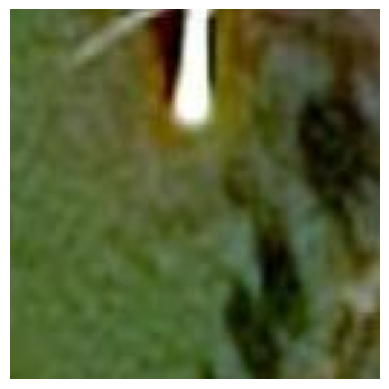

In [ ]:
# Chargement de l'image avec PIL
img_path = data_dir + '/train/target/C254372785.jpg'
img = Image.open(img_path)

# Afficher l'image
plt.imshow(img)
plt.axis('off')  # Masquer les axes
plt.show()

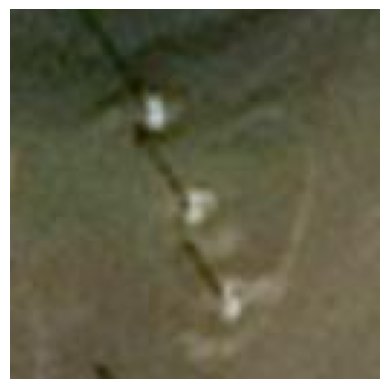

Taille de l'image (other):  torch.Size([3, 128, 128])


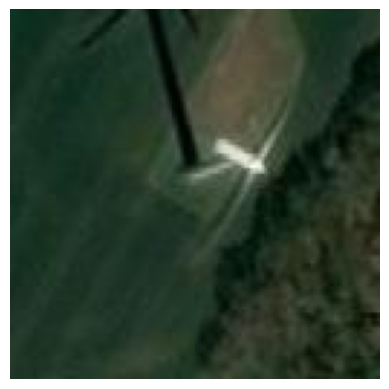

Premier canal de l'image (tensor): tensor([[0.2549, 0.2549, 0.2431,  ..., 0.2431, 0.2588, 0.2745],
        [0.2353, 0.2392, 0.2275,  ..., 0.2588, 0.2667, 0.2745],
        [0.2157, 0.2196, 0.2118,  ..., 0.2863, 0.2902, 0.2863],
        ...,
        [0.3608, 0.3647, 0.3686,  ..., 0.4588, 0.4627, 0.4667],
        [0.3804, 0.3804, 0.3765,  ..., 0.4510, 0.4549, 0.4588],
        [0.4039, 0.3961, 0.3843,  ..., 0.4392, 0.4431, 0.4431]])


In [ ]:
# Définir la transformation ToTensor
to_tensor = transforms.ToTensor()


# Visualiser une autre image
img_other_path = data_dir + '/train/target/C258215971.jpg'
img_other = Image.open(img_other_path)
img_other_tensor = to_tensor(img_other)

# Afficher l'autre image et sa taille
plt.imshow(img_other)
plt.axis('off')
plt.show()
print("Taille de l'image (other): ", img_other_tensor.shape)


# Afficher une image du jeu de validation
img_val_path = data_dir + '/validation/target/C272131162.jpg'
img_val = Image.open(img_val_path)
plt.imshow(img_val)
plt.axis('off')
plt.show()

# Affichage du premier canal de l'image "other" (le canal rouge dans RGB)
print("Premier canal de l'image (tensor):", img_other_tensor[0, :, :])


## Méthode de base : régression logistique

On donne ci-dessous un exemple de code qui permet d'implémenter une méthode de  régression logistique, de calculer l'erreur de classification sur l'ensemble d'apprentissage, et donner la prédiction des classes sur l'ensemble test.

### Réseau de neurones à une seule couche

On rappelle que la formulation du modèle de régression logistique peut s'interpréter comme la construction d'un réseau de neurones à une seule couche (les entrées) avec deux neurones de sortie, et l'utilisation de la sigmoïde comme fonction d'activation ainsi que de la cross-entropy comme terme d'attache aux données. Les paramètres d'un tel réseau de neurones peuvent être estimés à l'aide de l'algorithme de descente de gradient stochastique `SGD` ou de l'algorithme ``ADAM`` qui est implémenté dans la librairie `PyTorch`, et dont un exemple d'utilisation est présenté dans le code ci-dessous. Ce code est également une illustration de l'utilisation des réseaux de neurones pour la classification d'images à partir de leur lecture dans un dossier sans importer l'ensemble de la base d'apprentissage (via des DataLoader). L'ensemble des images est en effet trop gros pour être entièrement chargé dans la mémoire.

Régression Logistique:
$$ f_\theta(x) = \mathrm{Sigmoid}\left(W_1 x + b_1\right)$$
Le critère d'entropy croisée binaire (binary cross-entropy), entre $y$ et $f_\theta(x)$ est ensuite exactement équivalent à la régression logistique

In [20]:
# Paramètres
nb_classes = 2
batch_size = 100
img_width = 128
img_height = 128


# Définir les transformations pour normaliser les images
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((img_width, img_height)),  # Redimensionner les images
        transforms.ToTensor(),  # Convertir les images en tenseur PyTorch
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Normaliser les images
    ]),
    'val': transforms.Compose([
        transforms.Resize((img_width, img_height)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Charger les ensembles d'entraînement et de validation
train_dataset = datasets.ImageFolder(data_dir + '/train', transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(data_dir + '/validation', transform=data_transforms['val'])

# Créer les DataLoaders pour charger les images par lots
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Obtenir les classes
class_names = train_dataset.classes
print(f"Classes: {class_names}")

Classes: ['other', 'target']


In [ ]:
# Définition d'un réseau de neurones basique en PyTorch sans activation
class BasicModel(torch.nn.Module):
    def __init__(self):
        super(BasicModel, self).__init__()
        ################ajouté
        self.conv_layers = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),

            torch.nn.Conv2d(64, 128, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),
        )
        self.fc_layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(128 * 16 * 16, 256),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(256, 2)  # sortie = 2 classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x
        #
        #
        # À completer
        #
        #
        # Couche Flatten
        #self.flatten = torch.nn.Flatten()
        # Couche Dense avec 2 neurones de sortie (classification binaire)
        #self.fc = torch.nn.Linear(img_width * img_height * 3, 2)  # Sortie de 2 logits


    #def forward(self, x):
        #x = self.flatten(x)
        #x = self.fc(x)  # Sortie directe des logits
        #return x


# Instanciation du modèle
model = BasicModel()

# Optimiseur Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Définir la fonction de perte avec CrossEntropyLoss (elle inclut Softmax)
criterion = torch.nn.CrossEntropyLoss()

# Affichage de la structure du modèle
print(model)

BasicModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [ ]:
# Obtenir de l'aide sur les couches et fonctions PyTorch
# help(torch.nn.Linear)  # Equivalent de Dense
# help(torch.nn.Conv2d)  # Convolution 2D
# help(torch.nn.MaxPool2d)  # Max pooling 2D
# help(torch.nn.AvgPool2d)  # Average pooling 2D
# help(torch.nn.Dropout)  # Dropout

#help(model)  # Pour obtenir des informations sur le modèle défini en PyTorch

In [ ]:
# Déterminer si on utilise le GPU ou le CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialiser le modèle et le transférer sur le GPU si disponible
model = BasicModel().to(device)

# Définir l'optimiseur après avoir déplacé le modèle sur le GPU
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Définir la fonction de perte et la transférer sur le GPU
criterion = torch.nn.CrossEntropyLoss().to(device)

# Taille des batchs et nombre d'epochs
epochs = 10


###########liste ajouté
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
# Initialisation des meilleurs scores
best_val_loss = float('inf')
best_val_acc = 0.0



# Boucle d'entraînement
for epoch in tqdm(range(epochs), leave=False): #tqdm permet de faire des barres de progression, c'est optionnel
    print(f"Epoch {epoch+1}/{epochs}")

    model.train()  # Mettre le modèle en mode entraînement
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, leave=False):
        # Transférer les données sur le GPU de manière automatique
        images, labels = images.to(device), labels.to(device)


        # Calcul du modèle et de la loss (Forward)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation et optimization
        optimizer.zero_grad() # Remettre les gradients à 0
        loss.backward()
        optimizer.step()

        # Calcul de la fonction cout et de la précision (accumulés par epoch)
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.shape[0]

        ############### ajouté, changer le epoch si meilleur
        # Sauvegarde du meilleur modèle basé sur la validation
        # Ici on sauvegarde si la perte diminue OU si l'accuracy augmente
        if val_epoch_loss < best_val_loss or val_epoch_acc > best_val_acc:
          print("✅ Meilleur modèle trouvé. Sauvegarde des poids...")
          torch.save(model.state_dict(), 'final_model_trained_weights.pth')
          best_val_loss = val_epoch_loss
          best_val_acc = val_epoch_acc


    # Afficher la perte et l'accuracy pour cette époque
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    ##############ajout à la liste
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

    # Validation
    model.eval()  # Mettre le modèle en mode évaluation
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # Désactiver la propagation des gradients
        for images, labels in val_loader:
            # Transférer les données de validation sur le GPU
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.shape[0]

    # Afficher les résultats à chaque epoch
    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = val_correct / val_total

    ##############ajout à la liste
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    print(f"Validation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_epoch_acc:.4f}")


## Sauvegarde des poids du modèle
torch.save(model.state_dict(), 'final_model_trained_weights.pth')


print(f"Les meilleures valeurs sont, pour le loss : {best_val_loss} et pour l'accuracy : {best_val_acc}")


import matplotlib.pyplot as plt

# Courbe de loss
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Courbe d’accuracy
plt.figure()
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

Using device: cuda


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10


  0%|          | 0/4 [00:00<?, ?it/s]

NameError: name 'val_epoch_loss' is not defined

In [ ]:
# Obtenir la correspondance des classes avec leurs indices
label_map = train_dataset.class_to_idx
print(label_map)

{'other': 0, 'target': 1}


#Code final

In [ ]:
# ============================================================
# 🔹 Seed pour reproductibilité
# ============================================================
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# 🔹 Paramètres
# ============================================================
batch_size = 32  # plus petit batch pour transfert learning   (32 de base)
img_width = 128  # ResNet18 attend 224x224    (on test avec 128x128 à la place)
img_height = 128
data_dir = '/content/drive/MyDrive/Data_Projet_1_Defi_IA'
epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 🔹 Vérification des dossiers
# ============================================================
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'validation')
if not os.path.exists(train_dir) or not os.path.exists(val_dir):
    raise FileNotFoundError("Vérifie que tes dossiers train/validation existent dans Data_Small")

# ============================================================
# 🔹 Data augmentation
# ============================================================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((img_width, img_height)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(0.1, 0.1, 0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((img_width, img_height)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])
print(f"Nombre d'images dans le jeu d'entraînement : {len(train_dataset)}")
print(f"Nombre d'images dans le jeu de validation : {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
class_names = train_dataset.classes
nb_classes = len(class_names)
print(f"Classes: {class_names}, Nb classes: {nb_classes}")

# ============================================================
# 🔹 Modèle : ResNet18 pré-entraîné
# ============================================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Remplacer la dernière couche fully connected
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, nb_classes)
model = model.to(device)

# ============================================================
# 🔹 Optimiseur et loss
# ============================================================
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# ============================================================
# 🔹 Entraînement avec checkpoint
# ============================================================
best_val_acc = 0.0
best_val_loss = 100
best_epoch = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in tqdm(range(epochs), leave=False):
    print(f"\nEpoch {epoch+1}/{epochs}")
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = val_correct / val_total
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_acc)
    print(f"Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f}")

    # Checkpoint
    if val_epoch_acc >= best_val_acc and best_val_loss >= val_epoch_loss :
        best_val_acc = val_epoch_acc
        best_val_loss = val_epoch_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'final_model_trained_weights.pth')
        print(f"✅ Nouveau meilleur modèle sauvegardé à l'epoch {best_epoch}")
        torch.save(model.state_dict(), '/content/drive/MyDrive/final_model_trained_weights.pth')
        print("📁 Copie de sauvegarde enregistrée dans le Drive")


    scheduler.step()

print(f"\nMeilleur modèle obtenu à l'epoch {best_epoch} avec Val Accuracy = {best_val_acc:.4f}")

# ============================================================
# 🔹 Courbes Loss et Accuracy
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Évolution de la Loss')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Évolution de l\'Accuracy')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Nombre d'images dans le jeu d'entraînement : 58407
Nombre d'images dans le jeu de validation : 4994
Classes: ['other', 'target'], Nb classes: 2


  0%|          | 0/5 [00:00<?, ?it/s]


Epoch 1/5



100%|██████████| 1826/1826 [3:51:33<00:00,  5.59s/it]
                                                     

Train Loss: 0.0917 | Train Acc: 0.9673
Val Loss: 0.0744 | Val Acc: 0.9746
✅ Nouveau meilleur modèle sauvegardé à l'epoch 1


...

Train Loss: 0.0655 | Train Acc: 0.9771
Val Loss: 0.0679 | Val Acc: 0.9780
✅ Nouveau meilleur modèle sauvegardé à l'epoch 2


 40%|████      | 2/5 [6:04:21<8:27:26, 10148.80s/it] 

📁 Copie de sauvegarde enregistrée dans le Drive

Epoch 3/5



 63%|██████▎   | 1151/1826 [1:06:27<45:12,  4.02s/it]


KeyboardInterrupt: 

In [12]:
state_dict = torch.load("final_model_trained_weights.pth")

# Ajouter le préfixe "model." pour correspondre à self.model (petit problème de raccord donc on raccorde manuellement)
new_state_dict = { "model." + k: v for k, v in state_dict.items() }

torch.save(new_state_dict, "final_model_trained_weights.pth")
print("✅ Poids prêts pour final_model() avec self.model")


✅ Poids prêts pour final_model() avec self.model


In [18]:
# ===== ÉVAL SEULEMENT : calcule l'accuracy de validation jeu de données du modèle sauvegardé =====
# on reteste les jeux de données pour voir si les poids sont bons ( on avait fait avec le petit jeu de données au final)
import os, torch, numpy as np
import torch.nn as nn
from torchvision.transforms import InterpolationMode
from torch.amp import autocast

# 1) Chemin vers la validation (avec le raccourci placé dans Mon Drive)
val_dir = '/content/drive/MyDrive/Data_Projet_1_Defi_IA/validation'  # ajuster si besoin
assert os.path.exists(val_dir), f"Chemin introuvable: {val_dir}"

# 2) Transforms identiques à l'entraînement
img_width = img_height = 128
data_transforms_val = transforms.Compose([
    transforms.Resize((img_height, img_width), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# 3) Dataset + DataLoader
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms_val)
val_loader  = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

class_names = val_dataset.classes
nb_classes = len(class_names)
print(f"Val images: {len(val_dataset)} | Classes: {class_names}")

# 4) Modèle (même architecture que celle utilisée pour sauvegarder les poids)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class final_model(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(final_model, self).__init__()
        self.model = models.resnet18(weights=None)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

model = final_model(num_classes=nb_classes).to(device)

# 5) Charger les poids
weights_path = 'final_model_trained_weights.pth'  # le meilleur checkpoint
state = torch.load(weights_path, map_location=device)
model.load_state_dict(state)
model.eval()

# 6) (Option) TTA simple (original + flip horizontal)
USE_TTA = False
def tta_predict(m, images):
    outs = []
    outs.append(m(images))
    outs.append(m(torch.flip(images, dims=[3])))
    return torch.stack(outs).mean(0)

# 7) Boucle d’évaluation
correct, total = 0, 0
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
with torch.no_grad(), autocast(device_type=device_type, enabled=(device_type=='cuda')):
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        logits = tta_predict(model, images) if USE_TTA else model(images)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

val_acc = correct / max(1, total)
print(f"✅ Accuracy sur {val_dir}: {val_acc:.4f}")


Val images: 326 | Classes: ['other', 'target']
✅ Accuracy sur /content/drive/MyDrive/Data_Small/train: 1.0000


# Code pour l'évaluation finale

## **Partie à modifier en suivant les consignes** Important de votre modèle final, entraîné
**Consignes:**
* Seule cette partie sera exécutée pour l'évaluation finale (tout ce qui est au dessus sera ignoré)
* Il vous est demandé de remettre votre architecture ici, en appelant la classe final_model (voir le code ci-dessous). Ne changez que la définition du final_model et sa fonction `forward`, **mais pas le nom de la classe**
* Votre modèle doit avoir été entrainé, et vous devez avoir sauvergardé la valeur des paramètres du modèle entrainé avec `torch.save` pour qu'il n'y ai plus qu'à charger le modèle.
* **Important** le nom du fichier qui charge les poids ne doit pas être changé: `final_model_trained_weights.pth`

In [13]:
import torchvision.models as models
import torch.nn as nn

class final_model(torch.nn.Module):
    def __init__(self):
        super(final_model, self).__init__()
        self.model = models.resnet18(weights=None)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, 2)
    def forward(self, x):
        x = self.model(x)
        return x

In [14]:
model = final_model() # à changez éventuellement en fonction de votre modèle
model.load_state_dict(torch.load('final_model_trained_weights.pth', weights_only=True))

<All keys matched successfully>

## **Ne pas modifier:** Exportation des résultats pour évaluation finale

In [23]:
import os
import pandas as pda

# Définir la transformation pour les images de test
data_transforms['test'] = transforms.Compose([
    transforms.Resize((img_width, img_height)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Charger les images de test
prediction_dir = data_dir + "/evaluation_finale/"
test_dataset = datasets.ImageFolder(prediction_dir, transform=data_transforms['test'])
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Mettre le modèle en mode évaluation
model.eval()

# Liste pour stocker les prédictions
predictions = []
img_names = []

# Faire des prédictions sur les images de test
with torch.no_grad():
    for inputs, _ in tqdm(test_loader, leave=False):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        predictions.append(predicted.item())

### LES LIGNES SUIVANTES SONT À NE PAS TOUCHER!
### Elles servent à creer un fichier que vous devez fournir dans le rendu.
### Ce fichier garde les predictions dans un format qui nous permet de verifier par rapport aux vraies étiquettes.

# Extraire les noms des fichiers d'images depuis test_dataset.samples
file_paths = [sample[0] for sample in test_dataset.samples]
img_names = [os.path.basename(path) for path in file_paths]  # Obtenir juste le nom du fichier image

# Créer un DataFrame avec les résultats
results_df = pda.DataFrame({'name': img_names, 'prediction': predictions})

# Sauvegarder le fichier dans le format souhaité : name;prediction
results_df.to_csv(data_dir + '/predictions.csv', index=False, sep=';')

In [ ]:
import numpy as np
true_target = np.arange(len(test_loader), dtype=float) < int(len(test_loader) / 2)
print('Accuracy:', np.sum(results_df['prediction'] == true_target) / len(test_loader) * 100, '%')